<a href="https://colab.research.google.com/github/Juuphaada/Machine-Learning-Study/blob/main/mexico_optimisation%26testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook introduction
- Get a processed datasets and features choices from the previous notebook (mexico_dataVisualization_featureSelection.ipynb)
- Find the best dataset and features choices for each candidate models
- Find the best models hyperparameter


#### **Candidate Models**
*   Support Vector Machine (SVM)
*   Random Forest (RF)
*   K-Nearest Neighbors (KNNs)
*   Artificial Neural Network (ANNs)

#### **Datasets**
*   StandardScaler dataset - dataset that features are standardized by removing the mean and scaling to unit variance.
*   QuantileTransformer dataset - dataset that features are transformed to follow a uniform or normal distribution by mapping data to quantiles.

#### **Features selection choices**
- Set of features selected by filtering MI score
- Set of features selected by filtering MI score & remove feature redundancy

# Set-up & Get data

In [1]:
!pip install --upgrade scikeras

In [2]:
!pip install "scikit-learn<1.6.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 51.6 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


In [3]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from scikeras.wrappers import KerasClassifier
import numpy as np
from datetime import datetime
from dateutil import tz
date_time_stamp = datetime.now(tz=tz.tzlocal()).strftime("%Y%m%d_%H%M%S")

In [4]:
# get data that already processed from the previous notebook
df_std_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Researching/Maxico_std_train.csv")
df_std_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Researching/Maxico_std_test.csv")
df_trans_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Researching/Maxico_trans_train.csv")
df_trans_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Researching/Maxico_trans_test.csv")

In [5]:
df_std_train

,FOLIO_I,sexo,edad,concentracion_hemoglobina,temperatura_ambiente,valor_acido_urico,valor_albumina,valor_colesterol_hdl,valor_colesterol_ldl,valor_colesterol_total,...,segundamedicion_peso,segundamedicion_estatura,distancia_rodilla_talon,circunferencia_de_la_pantorrilla,segundamedicion_cintura,tension_arterial,sueno_horas,masa_corporal,actividad_total,riesgo_hipertension
0,2022_29007020,1,1.224349,0.584050,-4.544454,-2.057126,-1.262050,2.470942,3.947406,2.935709,...,0.093873,0.265655,-0.086564,-0.149400,-2.162459,-0.181016,-0.086384,-1.742209,0.086375,0
1,2022_17011055,0,1.085882,1.279950,0.193968,3.673023,-2.592937,0.862396,1.151894,0.526518,...,0.077449,1.930072,0.261721,-0.247558,-2.270502,-0.099796,-0.086384,-1.742209,-0.091765,1
2,2022_15033029,1,0.739716,0.497063,0.193968,-0.106437,-1.483865,0.119991,0.752535,1.341391,...,-0.152489,-0.044004,-0.066662,-0.113706,0.495799,-0.099796,-0.446359,0.534569,0.264516,1
3,2022_02002048,0,-0.160317,-0.024862,0.193968,0.015481,0.290652,-0.251212,-0.103234,-0.182067,...,-0.152489,-0.044004,-0.066662,-0.113706,0.495799,-0.208089,0.273591,0.828710,-0.225370,1
4,2022_16019018,0,-0.575717,1.366937,1.141652,2.210006,2.286983,3.955753,3.034586,2.900279,...,-0.152489,-0.044004,-0.066662,-0.113706,0.495799,-0.289310,-0.086384,0.612813,0.086375,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3485,2022_25006025,0,0.462782,-0.024862,0.193968,0.015481,0.290652,-0.251212,-0.103234,-0.182067,...,-0.152489,-0.044004,-0.066662,-0.113706,0.495799,-0.208089,0.273591,-0.113961,0.353586,0
3486,2022_05024003,0,0.047383,1.366937,1.457547,1.234662,0.290652,0.491194,0.695484,0.526518,...,-0.152489,-0.044004,-0.066662,-0.113706,0.495799,-0.194553,-0.086384,0.613256,-0.225370,1
3487,2022_21114014,1,0.393549,1.540912,0.193968,-1.447536,-1.040236,0.738662,-0.787849,-0.607219,...,-0.152489,-0.044004,-0.066662,-0.113706,0.495799,0.292769,0.273591,0.794355,0.398121,1
3488,2022_27013025,0,-1.268050,2.758736,0.825758,0.015481,1.621539,1.109865,4.175611,2.581416,...,-0.152489,-0.044004,-0.066662,-0.113706,0.495799,0.103255,-0.446359,0.864622,-0.106610,1


In [ ]:
df_std_test

,FOLIO_I,sexo,edad,concentracion_hemoglobina,temperatura_ambiente,valor_acido_urico,valor_albumina,valor_colesterol_hdl,valor_colesterol_ldl,valor_colesterol_total,...,segundamedicion_peso,segundamedicion_estatura,distancia_rodilla_talon,circunferencia_de_la_pantorrilla,segundamedicion_cintura,tension_arterial,sueno_horas,masa_corporal,actividad_total,riesgo_hipertension
0,2022_02004025,0,-1.614217,-0.024862,0.193968,0.015481,0.290652,-0.251212,-0.103234,-0.182067,...,-0.152489,-0.044004,-0.066662,-0.113706,0.495799,-0.181016,0.273591,0.871207,-0.002695,1
1,2022_22014004,0,0.116616,-0.024862,0.193968,0.015481,0.290652,-0.251212,-0.103234,-0.182067,...,-0.152489,-0.044004,-0.066662,-0.113706,0.495799,-0.099796,-0.806335,0.600739,0.049263,1
2,2022_19031049,1,-0.091084,-0.024862,0.193968,0.015481,0.290652,-0.251212,-0.103234,-0.182067,...,-0.152489,-0.044004,-0.066662,-0.113706,0.495799,0.008498,-0.806335,0.949715,0.353586,1
3,2022_16043020,1,-0.991117,0.149113,0.193968,-0.716028,1.177910,1.357333,-0.673746,0.207655,...,-0.152489,-0.044004,-0.066662,-0.113706,0.495799,-0.505897,0.273591,-0.086306,-0.581651,1
4,2022_12007020,0,1.224349,1.453924,0.193968,0.746989,-1.705679,0.243725,-0.730798,-0.500931,...,0.854859,1.407523,0.022897,0.037993,-2.023838,0.279232,-0.446359,-1.742209,0.086375,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
868,2022_07087012,0,-1.752683,-0.024862,0.193968,0.015481,0.290652,-0.251212,-0.103234,-0.182067,...,-0.152489,-0.044004,-0.066662,-0.113706,0.495799,-0.275773,0.633566,-0.419735,-0.470314,1
869,2022_13027019,1,-0.921884,-0.024862,0.193968,0.015481,0.290652,-0.251212,-0.103234,-0.182067,...,-0.152489,-0.044004,-0.066662,-0.113706,0.495799,-0.384067,0.273591,0.270801,-0.180835,1
870,2022_15106030,1,1.016649,-0.024862,0.193968,0.015481,0.290652,-0.251212,-0.103234,-0.182067,...,-0.075843,-2.405153,-0.594065,0.011222,0.495799,0.360453,0.633566,-1.742209,-0.391635,0
871,2022_06009054,1,0.047383,-0.024862,0.193968,0.015481,0.290652,-0.251212,-0.103234,-0.182067,...,-0.152489,-0.044004,-0.066662,-0.113706,0.495799,0.076182,0.273591,0.776908,-0.514849,1


In [ ]:
df_trans_train

,edad,concentracion_hemoglobina,temperatura_ambiente,valor_acido_urico,valor_albumina,valor_colesterol_hdl,valor_colesterol_ldl,valor_colesterol_total,valor_creatina,resultado_glucosa,...,distancia_rodilla_talon,circunferencia_de_la_pantorrilla,segundamedicion_cintura,tension_arterial,sueno_horas,masa_corporal,actividad_total,FOLIO_I,sexo,riesgo_hipertension
0,1.210137,1.114032,-2.696511,-1.817968,-1.292465,1.942703,2.408550,2.074445,1.035790,1.324958,...,-1.312981,-1.625274,-1.654145,-0.231641,-0.195700,-5.199338,0.530745,2022_29007020,2,0
1,1.025123,1.381364,0.079120,2.325972,-1.761948,1.215372,1.358913,1.100140,2.797301,2.427442,...,1.721914,-1.851734,-1.989660,0.080379,-0.195700,-5.199338,0.138444,2022_17011055,1,1
2,0.653377,1.079690,0.079120,-0.977487,-1.371657,0.905189,1.223287,1.418119,1.154615,-1.123415,...,-0.016310,-0.124523,5.199338,0.080379,-0.823172,0.457531,0.947580,2022_15033029,2,1
3,-0.232930,-0.030114,0.079120,0.046436,0.138444,-0.156199,-0.042668,-0.096753,-0.127052,0.030114,...,-0.016310,-0.124523,5.199338,-0.391137,0.553999,1.046345,-0.184203,2022_02002048,1,1
4,-0.523537,1.428482,1.705570,1.798663,2.784622,2.511791,2.063775,2.063775,2.211127,0.030114,...,-0.016310,-0.124523,5.199338,-0.805692,-0.195700,0.620791,0.530745,2022_16019018,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3485,0.378977,-0.030114,0.079120,0.046436,0.138444,-0.156199,-0.042668,-0.096753,-0.127052,0.030114,...,-0.016310,-0.124523,5.199338,-0.391137,0.553999,-0.599931,1.137677,2022_25006025,1,0
3486,-0.032625,1.428482,1.837975,1.494155,0.138444,1.048748,1.202347,1.100140,1.750222,1.324958,...,-0.016310,-0.124523,5.199338,-0.283522,-0.195700,0.621466,-0.184203,2022_05024003,1,1
3487,0.312376,1.517545,0.079120,-1.479004,-1.218002,1.157061,-1.327982,-1.371657,1.084195,1.629992,...,-0.016310,-0.124523,5.199338,1.269664,0.553999,0.982821,1.242061,2022_21114014,2,1
3488,-1.137677,2.107953,1.602210,0.046436,2.225823,1.321946,2.492098,1.936181,1.550085,-1.044409,...,-0.016310,-0.124523,5.199338,0.741388,-0.823172,1.119649,0.090452,2022_27013025,1,1


In [ ]:
df_trans_test

,edad,concentracion_hemoglobina,temperatura_ambiente,valor_acido_urico,valor_albumina,valor_colesterol_hdl,valor_colesterol_ldl,valor_colesterol_total,valor_creatina,resultado_glucosa,...,distancia_rodilla_talon,circunferencia_de_la_pantorrilla,segundamedicion_cintura,tension_arterial,sueno_horas,masa_corporal,actividad_total,FOLIO_I,sexo,riesgo_hipertension
0,-1.562721,-0.030114,0.079120,0.046436,0.138444,-0.156199,-0.042668,-0.096753,-0.127052,0.030114,...,-0.016310,-0.124523,5.199338,-0.231641,0.553999,1.132464,0.332198,2022_02004025,1,1
1,0.032625,-0.030114,0.079120,0.046436,0.138444,-0.156199,-0.042668,-0.096753,-0.127052,0.030114,...,-0.016310,-0.124523,5.199338,0.080379,-5.199338,0.593002,0.452955,2022_22014004,1,1
2,-0.163824,-0.030114,0.079120,0.046436,0.138444,-0.156199,-0.042668,-0.096753,-0.127052,0.030114,...,-0.016310,-0.124523,5.199338,0.457033,-5.199338,1.279050,1.137677,2022_19031049,2,1
3,-0.858910,0.951518,0.079120,-1.174387,1.880352,1.439001,-1.283836,0.989697,1.084195,1.132898,...,-0.016310,-0.124523,5.199338,-1.858747,0.553999,-0.575550,-1.606755,2022_16043020,2,1
4,1.210137,1.467860,0.079120,1.307063,-1.439001,0.951518,-1.304121,-1.324958,1.411293,1.223287,...,1.343287,1.174387,-1.315958,1.236652,-0.823172,-5.199338,0.530745,2022_12007020,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
868,-1.727466,-0.030114,0.079120,0.046436,0.138444,-0.156199,-0.042668,-0.096753,-0.127052,0.030114,...,-0.016310,-0.124523,5.199338,-0.748009,1.554270,-0.752513,-1.081940,2022_07087012,1,1
869,-0.809168,-0.030114,0.079120,0.046436,0.138444,-0.156199,-0.042668,-0.096753,-0.127052,0.030114,...,-0.016310,-0.124523,5.199338,-1.236652,0.553999,-0.073023,-0.080379,2022_13027019,2,1
870,0.943656,-0.030114,0.079120,0.046436,0.138444,-0.156199,-0.042668,-0.096753,-0.127052,0.030114,...,-2.408550,1.135284,5.199338,1.435477,1.554270,-5.199338,-0.732827,2022_15106030,2,0
871,-0.032625,-0.030114,0.079120,0.046436,0.138444,-0.156199,-0.042668,-0.096753,-0.127052,0.030114,...,-0.016310,-0.124523,5.199338,0.653377,0.553999,0.954564,-1.231280,2022_06009054,2,1


In [8]:
# get standard scaler dataset
X_std_train = df_std_train.drop(columns=['FOLIO_I', 'riesgo_hipertension'])
y_std_train = df_std_train['riesgo_hipertension']
# get quartile transformer dataset
X_trans_train = df_trans_train.drop(columns=['FOLIO_I', 'riesgo_hipertension'])
y_trans_train = df_trans_train['riesgo_hipertension']


In [7]:
# get features selection choice from the last notebook
# selected by filtering MI score
std_selected_feature = ['masa_corporal', 'peso', 'medida_cintura', 'edad', 'estatura', 'segundamedicion_cintura', 'circunferencia_de_la_pantorrilla', 'segundamedicion_estatura', 'distancia_rodilla_talon', 'segundamedicion_peso', 'actividad_total', 'tension_arterial', 'valor_colesterol_ldl', 'valor_homocisteina', 'valor_transferrina', 'valor_trigliceridos', 'valor_vitamina_bdoce', 'valor_colesterol_total', 'valor_vitamina_d', 'valor_albumina', 'valor_ferritina', 'valor_insulina', 'valor_hemoglobina_glucosilada', 'resultado_glucosa_promedio']
trans_selected_feature = ['masa_corporal', 'peso', 'medida_cintura', 'edad', 'estatura', 'segundamedicion_cintura', 'circunferencia_de_la_pantorrilla', 'distancia_rodilla_talon', 'segundamedicion_estatura', 'segundamedicion_peso', 'actividad_total', 'tension_arterial', 'valor_transferrina', 'valor_colesterol_ldl', 'valor_homocisteina', 'valor_trigliceridos', 'valor_vitamina_bdoce', 'valor_vitamina_d', 'valor_albumina', 'resultado_glucosa', 'valor_ferritina', 'valor_insulina']
# filtering MI score & remove redundancy feature
std_selected_feature_no_redun = ['masa_corporal', 'edad', 'estatura', 'segundamedicion_cintura', 'circunferencia_de_la_pantorrilla', 'segundamedicion_estatura', 'distancia_rodilla_talon', 'segundamedicion_peso', 'actividad_total', 'tension_arterial', 'valor_colesterol_ldl', 'valor_homocisteina', 'valor_transferrina', 'valor_trigliceridos', 'valor_vitamina_bdoce', 'valor_vitamina_d', 'valor_albumina', 'valor_ferritina', 'valor_insulina', 'valor_hemoglobina_glucosilada']
trans_selected_feature_no_redun = ['masa_corporal', 'edad', 'estatura', 'segundamedicion_cintura', 'circunferencia_de_la_pantorrilla', 'distancia_rodilla_talon', 'segundamedicion_estatura', 'segundamedicion_peso', 'actividad_total', 'tension_arterial', 'valor_transferrina', 'valor_colesterol_ldl', 'valor_homocisteina', 'valor_trigliceridos', 'valor_vitamina_bdoce', 'valor_vitamina_d', 'valor_albumina', 'resultado_glucosa', 'valor_ferritina', 'valor_insulina']

Some models good with data that done feature selection and no feature redundancy, some models doesn't need to do feature selection on data at all.

# Find the best dataset & set of features

### Get CV scores from comparisons of :
###different dataset
- StandardScelar dataset
- QuantileTransformer dataset
### and
###different set of features
- all features
- Feature selection by filtering MI score
- Feature selection by filtering MI score & remove feature redundancy

In [ ]:
# define ANNs model
def create_ann_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(5, activation='relu'),
        Dense(2, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy'
    )
    return model

In [ ]:
def cross_validation (X_train,y_train,features):
  svm_model = make_pipeline(SVC(kernel='rbf'))
  rf_model = RandomForestClassifier(n_estimators=100, random_state=42, min_samples_split=20, max_depth=15)
  knn_model = KNeighborsClassifier(n_neighbors=3)
  ann_model = KerasClassifier(model=create_ann_model(len(features)), epochs=100, batch_size=10, verbose=0)

  stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

  scoring_metrics = ['accuracy', 'precision', 'recall', 'f1']

  svm_cv_scores = cross_validate(
      estimator=svm_model,
      X=X_train[features],
      y=y_train,
      cv=stratified_kfold,
      scoring=scoring_metrics,
      return_train_score=False
  )

  rf_cv_scores = cross_validate(
      estimator=rf_model,
      X=X_train[features],
      y=y_train,
      cv=stratified_kfold,
      scoring=scoring_metrics,
      return_train_score=False
  )

  knn_cv_scores = cross_validate(
      estimator=knn_model,
      X=X_train[features],
      y=y_train,
      cv=stratified_kfold,
      scoring=scoring_metrics,
      return_train_score=False
  )

  ann_cv_scores = cross_validate(
      estimator=ann_model,
      X=X_train[features],
      y=y_train,
      cv=stratified_kfold,
      scoring=scoring_metrics,
      return_train_score=False
  )

  cv_score = pd.DataFrame(
  [
    [
      svm_cv_scores['test_accuracy'].mean(),
      rf_cv_scores['test_accuracy'].mean(),
      knn_cv_scores['test_accuracy'].mean(),
      ann_cv_scores['test_accuracy'].mean()
    ],
    [
      svm_cv_scores['test_precision'].mean(),
      rf_cv_scores['test_precision'].mean(),
      knn_cv_scores['test_precision'].mean(),
      ann_cv_scores['test_precision'].mean()
    ],
    [
      svm_cv_scores['test_recall'].mean(),
      rf_cv_scores['test_recall'].mean(),
      knn_cv_scores['test_recall'].mean(),
      ann_cv_scores['test_recall'].mean()
    ],
    [
      svm_cv_scores['test_f1'].mean(),
      rf_cv_scores['test_f1'].mean(),
      knn_cv_scores['test_f1'].mean(),
      ann_cv_scores['test_f1'].mean()
    ]
  ],
  index=[scoring_metrics],
  columns=['SVM', 'RF', 'KNNs', 'ANNs'])

  return cv_score

Using dataset with all features

In [ ]:
stdData_cv_score = cross_validation(X_std_train,y_std_train,X_std_train.columns);
transData_cv_score = cross_validation(X_trans_train,y_trans_train,X_trans_train.columns);

/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved o

In [ ]:
# save result
stdData_cv_score.to_csv(f'/content/drive/MyDrive/Colab Notebooks/Researching/compare_std_trans/stdData_cv_score_{date_time_stamp}.csv', index=True)
transData_cv_score.to_csv(f'/content/drive/MyDrive/Colab Notebooks/Researching/compare_std_trans/transData_cv_score_{date_time_stamp}.csv', index=True)

Using dataset with feature selection by filtering MI score

In [ ]:
trans_cv_score_selectedfeature = cross_validation(X_trans_train,y_trans_train,trans_selected_feature);
std_cv_score_selectedfeature = cross_validation(X_std_train,y_std_train,std_selected_feature);

/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved o

In [ ]:
std_cv_score_selectedfeature.to_csv(f'/content/drive/MyDrive/Colab Notebooks/Researching/compare_std_trans/std_cv_score_selectedfeature{date_time_stamp}.csv', index=True)
trans_cv_score_selectedfeature.to_csv(f'/content/drive/MyDrive/Colab Notebooks/Researching/compare_std_trans/trans_cv_score_selectedfeature{date_time_stamp}.csv', index=True)

Using dataset with feature selection by filtering MI score & remove feature redundancy

In [ ]:
std_cv_score_selectedfeature_no_redun = cross_validation(X_std_train,y_std_train,std_selected_feature_no_redun);
trans_cv_score_selectedfeature_no_redun = cross_validation(X_trans_train,y_trans_train,trans_selected_feature_no_redun);

/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved o

In [ ]:
std_cv_score_selectedfeature_no_redun.to_csv(f'/content/drive/MyDrive/Colab Notebooks/Researching/compare_std_trans/std_cv_score_selectedfeature_no_redun{date_time_stamp}.csv', index=True)
trans_cv_score_selectedfeature_no_redun.to_csv(f'/content/drive/MyDrive/Colab Notebooks/Researching/compare_std_trans/trans_cv_score_selectedfeature_no_redun{date_time_stamp}.csv', index=True)

# Get Best CV score (recall)
### Why Recall
For predicting the risk of hypertension in persons, false negative case is more costly than false positive case.


More recall score = less false negative.

In [ ]:
stdData_cv_score

,SVM,RF,KNNs,ANNs
accuracy,0.849857,0.985673,0.815186,0.897135
precision,0.855740,0.994622,0.841370,0.911849
recall,0.923174,0.983128,0.879663,0.930734
f1,0.888118,0.988836,0.860022,0.921143


In [ ]:
transData_cv_score

,SVM,RF,KNNs,ANNs
accuracy,0.880229,0.986533,0.861891,0.931805
precision,0.899193,0.995964,0.881469,0.943020
recall,0.917405,0.983129,0.908089,0.952050
f1,0.908150,0.989498,0.894563,0.947477


In [ ]:
std_cv_score_selectedfeature

,SVM,RF,KNNs,ANNs
accuracy,0.858739,0.987679,0.836103,0.878797
precision,0.869801,0.996407,0.855293,0.898120
recall,0.918738,0.984460,0.898325,0.916082
f1,0.893556,0.990397,0.876112,0.907001


In [ ]:
trans_cv_score_selectedfeature

,SVM,RF,KNNs,ANNs
accuracy,0.892837,0.987679,0.881662,0.892837
precision,0.910251,0.998195,0.897267,0.904040
recall,0.925398,0.982685,0.922293,0.932964
f1,0.917681,0.990376,0.909576,0.918207


In [ ]:
std_cv_score_selectedfeature_no_redun

,SVM,RF,KNNs,ANNs
accuracy,0.852722,0.987679,0.835244,0.887966
precision,0.860954,0.998196,0.854866,0.912936
recall,0.920512,0.982684,0.896992,0.913853
f1,0.889709,0.990376,0.875381,0.913290


In [ ]:
trans_cv_score_selectedfeature_no_redun

,SVM,RF,KNNs,ANNs
accuracy,0.882521,0.988539,0.870201,0.956734
precision,0.895757,0.999099,0.889694,0.967224
recall,0.925853,0.983129,0.912086,0.965808
f1,0.910471,0.991046,0.900692,0.966466


### **Result**

#### The best choises for each model ( for getting highest CV score of recall )
- SVM : Use QuantileTransformer dataset + feature selection & remove redundancy feature
- RF : Use QuantileTransformer dataset with using all features
- KNNs : Use QuantileTransformer dataset + feature selection
- ANNs : Use QuantileTransformer dataset + feature selection & remove redundancy feature

# Find the best models hyperparameter
Find the best setting of models parameters by iteration thru a range of values pair with values from other ranges, and get the pair with best CV score of recall.


#### Searching Method
- GridSearchCV : Evaluates all combinations.
- RandomizedSearchCV : Evaluates a subset of hyperparameter combinations.

Use
- SVM : GridSearch
- RF : RandomSearch + GridSearch
- KNNs : GraidSearch
- ANNs : RandomSearch + GridSearch

In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [10]:
# define base ANNs model
def create_custom_ann_model(input_dim, L1_units, L2_units, alpha, learning_rate_init):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(L1_units, activation='relu'),
        Dense(L2_units, activation='softmax', kernel_regularizer=l2(alpha))
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate_init),
        loss='sparse_categorical_crossentropy'
    )
    return model


In [11]:
# created base model
custom_svm_model = SVC(kernel = 'rbf')
custom_rf_model = RandomForestClassifier(random_state=42)
custom_knn_model = KNeighborsClassifier()
custom_ann_model = KerasClassifier(model=create_custom_ann_model, input_dim=len(trans_selected_feature_no_redun), epochs=100)

### SVM

In [ ]:
def svm_grid_search (svm_model, X, y):

  svm_params = {'C': [1,10,50,100,110], 'gamma': ['scale','auto']}

  Searching = GridSearchCV(custom_rf_model, svm_params ,cv=stratified_kfold, scoring='recall',refit=False,verbose = 5)
  Searching.fit(X, y)

  return Searching.best_params_ , Searching.best_score_

svm_grid_best_params, svm_grid_best_score = svm_grid_search(custom_svm_model, X_trans_train[trans_selected_feature_no_redun], y_trans_train)

In [ ]:
print(svm_grid_best_params)
print(svm_grid_best_score)

{'C': 100, 'gamma': 'auto'}
0.9502724809066272


### RF

In [ ]:
def rf_random_search (rf_model, X, y):
  rf_params = {
   'max_depth': list(range(5, 15)) + [None],
   'max_features': range(5,15),
   'min_samples_leaf': range(5,15),
   'min_samples_split': [5, 10, 15, 20],
   'n_estimators': [100,200,300,400,500]
  }

  Searching = RandomizedSearchCV(rf_model, rf_params, cv=stratified_kfold, scoring='recall',verbose = 5)
  Searching.fit(X, y)

  return Searching.best_params_ , Searching.best_score_

rf_bestRandom_params, rf_bestRandom_score = rf_random_search(custom_rf_model, X_trans_train, y_trans_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5] END max_depth=11, max_features=6, min_samples_leaf=11, min_samples_split=5, n_estimators=400;, score=0.989 total time=   3.3s
[CV 2/5] END max_depth=11, max_features=6, min_samples_leaf=11, min_samples_split=5, n_estimators=400;, score=0.980 total time=   2.5s
[CV 3/5] END max_depth=11, max_features=6, min_samples_leaf=11, min_samples_split=5, n_estimators=400;, score=0.976 total time=   2.4s
[CV 4/5] END max_depth=11, max_features=6, min_samples_leaf=11, min_samples_split=5, n_estimators=400;, score=0.980 total time=   2.7s
[CV 5/5] END max_depth=11, max_features=6, min_samples_leaf=11, min_samples_split=5, n_estimators=400;, score=0.980 total time=   1.9s
[CV 1/5] END max_depth=8, max_features=14, min_samples_leaf=12, min_samples_split=20, n_estimators=300;, score=0.989 total time=   2.0s
[CV 2/5] END max_depth=8, max_features=14, min_samples_leaf=12, min_samples_split=20, n_estimators=300;, score=0.982 total time=

In [ ]:
print(rf_bestRandom_params)
print(rf_bestRandom_score)

{'n_estimators': 300, 'min_samples_split': 20, 'min_samples_leaf': 12, 'max_features': 14, 'max_depth': 8}
0.9862330623306234


In [ ]:
def rf_grid_search (bestRandom_params, rf_model, X, y):
  max_depth = bestRandom_params['max_depth']
  max_features = bestRandom_params['max_features']
  min_samples_leaf = bestRandom_params['min_samples_leaf']
  min_samples_split = bestRandom_params['min_samples_split']
  n_estimators = bestRandom_params['n_estimators']

  rf_params = {
    'max_depth': [max_depth],
    'max_features': range(max_features-2,max_features+2),
    'min_samples_leaf': range(min_samples_leaf-2,min_samples_leaf+2),
    'min_samples_split': [min_samples_split],
    'n_estimators': [n_estimators]
  }

  Searching = GridSearchCV(rf_model, rf_params ,cv=stratified_kfold, scoring='recall',refit=False,verbose = 5)
  Searching.fit(X, y)

  return Searching.best_params_ , Searching.best_score_;


rf_grid_best_params, rf_grid_best_score = rf_grid_search(rf_bestRandom_params, custom_rf_model, X_trans_train, y_trans_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV 1/5] END max_depth=8, max_features=12, min_samples_leaf=10, min_samples_split=20, n_estimators=300;, score=0.989 total time=   2.0s
[CV 2/5] END max_depth=8, max_features=12, min_samples_leaf=10, min_samples_split=20, n_estimators=300;, score=0.982 total time=   1.9s
[CV 3/5] END max_depth=8, max_features=12, min_samples_leaf=10, min_samples_split=20, n_estimators=300;, score=0.984 total time=   1.9s
[CV 4/5] END max_depth=8, max_features=12, min_samples_leaf=10, min_samples_split=20, n_estimators=300;, score=0.989 total time=   1.9s
[CV 5/5] END max_depth=8, max_features=12, min_samples_leaf=10, min_samples_split=20, n_estimators=300;, score=0.984 total time=   2.5s
[CV 1/5] END max_depth=8, max_features=12, min_samples_leaf=11, min_samples_split=20, n_estimators=300;, score=0.989 total time=   2.7s
[CV 2/5] END max_depth=8, max_features=12, min_samples_leaf=11, min_samples_split=20, n_estimators=300;, score=0.982 total 

In [ ]:
print(rf_grid_best_params)
print(rf_grid_best_score)

{'max_depth': 8, 'max_features': 14, 'min_samples_leaf': 10, 'min_samples_split': 20, 'n_estimators': 300}
0.9866775067750677


### KNNs

In [ ]:
def knn_grid_search (knn_model, X, y):

  knn_params = {'n_neighbors': list(range(3, 11)),
                'weights': ['uniform', 'distance'],
                'p': [1, 2]}

  Searching = GridSearchCV(knn_model, knn_params, cv=stratified_kfold, scoring='recall',verbose = 5)
  Searching.fit(X, y)

  return Searching.best_params_ , Searching.best_score_

knn_grid_best_params, knn_grid_best_score = knn_grid_search(custom_knn_model, X_trans_train[trans_selected_feature], y_trans_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV 1/5] END n_neighbors=3, p=1, weights=uniform;, score=0.927 total time=   0.1s
[CV 2/5] END n_neighbors=3, p=1, weights=uniform;, score=0.922 total time=   0.1s
[CV 3/5] END n_neighbors=3, p=1, weights=uniform;, score=0.916 total time=   0.0s
[CV 4/5] END n_neighbors=3, p=1, weights=uniform;, score=0.920 total time=   0.1s
[CV 5/5] END n_neighbors=3, p=1, weights=uniform;, score=0.931 total time=   0.0s
[CV 1/5] END n_neighbors=3, p=1, weights=distance;, score=0.924 total time=   0.0s
[CV 2/5] END n_neighbors=3, p=1, weights=distance;, score=0.920 total time=   0.0s
[CV 3/5] END n_neighbors=3, p=1, weights=distance;, score=0.913 total time=   0.1s
[CV 4/5] END n_neighbors=3, p=1, weights=distance;, score=0.920 total time=   0.1s
[CV 5/5] END n_neighbors=3, p=1, weights=distance;, score=0.931 total time=   0.1s
[CV 1/5] END n_neighbors=3, p=2, weights=uniform;, score=0.924 total time=   0.0s
[CV 2/5] END n_neighbors=3, p=2

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 4, 5, 6, 7, 8, 9, 10], 'p': [1, 2],
                         'weights': ['uniform', 'distance']},
             scoring='recall', verbose=5)

In [ ]:
print(knn_grid_best_params)
print(knn_grid_best_score)

{'n_neighbors': 5, 'p': 1, 'weights': 'distance'}
0.933390490268539


### ANNs

In [ ]:
def ann_random_search (ann_model, X, y):

  ann_parems = {'batch_size' : [10, 16, 32, 64, 128],
                'model__L1_units':[8, 16, 32, 64],
                'model__L2_units': [4, 8, 16],
                'model__alpha': loguniform(1e-4, 1e-1),
                'model__learning_rate_init': loguniform(1e-3, 1e-1)
              }

  Searching = RandomizedSearchCV(estimator= ann_model,
                                    param_distributions= ann_parems,
                                    cv=stratified_kfold,
                                    scoring='recall',
                                    verbose = 5,
                                    random_state=42,
                                    n_jobs=-1,
                                    n_iter=10)
  Searching.fit(X, y)

  return Searching.best_params_ , Searching.best_score_

ann_bestRandom_params, ann_bestRandom_score = ann_random_search(custom_ann_model, X_trans_train[trans_selected_feature_no_redun], y_trans_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1.4561
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4250
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3795
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3724
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3589
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3490
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3304
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3269
Epoch 9/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3166
Epoch 10/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3115
Epoch 11/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3079
Epoch 12/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2997
Epoch 13/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2969
Epoch 14/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2928
Epoch 15/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2867
Epo

In [ ]:
print(ann_bestRandom_params)
print(ann_bestRandom_score)

{'batch_size': 64, 'model__L1_units': 8, 'model__L2_units': 16, 'model__alpha': np.float64(0.015702970884055395), 'model__learning_rate_init': np.float64(0.015751320499779727)}
0.9729026853904903


In [ ]:
def ann_grid_search (bestRandom_params, ann_model, X, y):

  batch_size = bestRandom_params['batch_size']
  L1_units = bestRandom_params['model__L1_units']
  L2_units = bestRandom_params['model__L2_units']
  alpha = bestRandom_params['model__alpha']
  learning_rate_init = bestRandom_params['model__learning_rate_init']

  ann_parems = {'batch_size' : [batch_size],
              'model__L1_units':[L1_units, L1_units*2, L1_units*4],
              'model__L2_units':[L2_units, L2_units*2, L2_units*4],
              'model__alpha': [alpha],
              'model__learning_rate_init': [learning_rate_init]
              }

  Searching = GridSearchCV(estimator= ann_model,
                                    param_grid = ann_parems,
                                    cv=stratified_kfold,
                                    scoring='recall',
                                    verbose = 5,
                                    n_jobs=-1)

  Searching.fit(X, y)

  return Searching.best_params_ , Searching.best_score_

ann_grid_best_params, ann_grid_best_score = ann_grid_search(ann_bestRandom_params , custom_ann_model, X_trans_train[trans_selected_feature_no_redun], y_trans_train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1.0342
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4077
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3745
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3579
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3409
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3361
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3241
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3164
Epoch 9/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3125
Epoch 10/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2886
Epoch 11/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2856
Epoch 12/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2726
Epoch 13/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2709
Epoch 14/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2659
Epoch 15/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2623
Epo

In [ ]:
print(ann_grid_best_params)
print(ann_grid_best_score)

{'batch_size': 64, 'model__L1_units': 16, 'model__L2_units': 32, 'model__alpha': np.float64(0.015702970884055395), 'model__learning_rate_init': np.float64(0.015751320499779727)}
0.9742468588322246


# Testing Models

In [15]:
from scipy.stats import randint, loguniform
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [16]:
# define ANNs model
def create_ann_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(16, activation='relu'),
        Dense(32, activation='softmax', kernel_regularizer=l2(0.015702970884055395))
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.015751320499779727),
        loss='sparse_categorical_crossentropy'
    )
    return model

In [17]:
def scoring (y_test, svm_predict, rf_predict, knn_predict, ann_predict):
  accuracy_list = []
  precision_list = []
  recall_list = []
  f1_list = []

  for predict in [svm_predict,rf_predict,knn_predict,ann_predict] :
    accuracy_list.append(accuracy_score(y_test, predict))
    precision_list.append(precision_score(y_test, predict))
    recall_list.append(recall_score(y_test, predict))
    f1_list.append(f1_score(y_test, predict))

  return pd.DataFrame(
      [accuracy_list,
       precision_list,
       recall_list,
       f1_list],
      index=['accuracy', 'precision', 'recall', 'f1'],
      columns=['SVM', 'RF', 'KNNs', 'ANNs'])

In [18]:
# final result
def final_prediction (X_train, X_test, y_train, y_test) :
  svm_model = make_pipeline(SVC(kernel='rbf'))
  rf_model = RandomForestClassifier(n_estimators=300, random_state=42, min_samples_split=20, max_depth=8, max_features=14, min_samples_leaf=10 )
  knn_model = KNeighborsClassifier(n_neighbors=5, p=1, weights='distance')
  ann_model = KerasClassifier(model=create_ann_model(len(trans_selected_feature_no_redun)), epochs=100, batch_size=64, verbose=0)

  svm_model.fit(X_train[trans_selected_feature_no_redun], y_train)
  svm_predict = svm_model.predict(X_test[trans_selected_feature_no_redun])

  rf_model.fit(X_train, y_train)
  rf_predict= rf_model.predict(X_test)

  knn_model.fit(X_train[trans_selected_feature], y_train)
  knn_predict = knn_model.predict(X_test[trans_selected_feature])

  ann_model.fit(X_train[trans_selected_feature_no_redun], y_train)
  ann_predict = ann_model.predict(X_test[trans_selected_feature_no_redun])

  scores = scoring(y_test, svm_predict, rf_predict, knn_predict, ann_predict)

  return scores , svm_model, rf_model, knn_model, ann_model

In [ ]:
df_trans_test

,edad,concentracion_hemoglobina,temperatura_ambiente,valor_acido_urico,valor_albumina,valor_colesterol_hdl,valor_colesterol_ldl,valor_colesterol_total,valor_creatina,resultado_glucosa,...,distancia_rodilla_talon,circunferencia_de_la_pantorrilla,segundamedicion_cintura,tension_arterial,sueno_horas,masa_corporal,actividad_total,FOLIO_I,sexo,riesgo_hipertension
0,-1.562721,-0.030114,0.079120,0.046436,0.138444,-0.156199,-0.042668,-0.096753,-0.127052,0.030114,...,-0.016310,-0.124523,5.199338,-0.231641,0.553999,1.132464,0.332198,2022_02004025,1,1
1,0.032625,-0.030114,0.079120,0.046436,0.138444,-0.156199,-0.042668,-0.096753,-0.127052,0.030114,...,-0.016310,-0.124523,5.199338,0.080379,-5.199338,0.593002,0.452955,2022_22014004,1,1
2,-0.163824,-0.030114,0.079120,0.046436,0.138444,-0.156199,-0.042668,-0.096753,-0.127052,0.030114,...,-0.016310,-0.124523,5.199338,0.457033,-5.199338,1.279050,1.137677,2022_19031049,2,1
3,-0.858910,0.951518,0.079120,-1.174387,1.880352,1.439001,-1.283836,0.989697,1.084195,1.132898,...,-0.016310,-0.124523,5.199338,-1.858747,0.553999,-0.575550,-1.606755,2022_16043020,2,1
4,1.210137,1.467860,0.079120,1.307063,-1.439001,0.951518,-1.304121,-1.324958,1.411293,1.223287,...,1.343287,1.174387,-1.315958,1.236652,-0.823172,-5.199338,0.530745,2022_12007020,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
868,-1.727466,-0.030114,0.079120,0.046436,0.138444,-0.156199,-0.042668,-0.096753,-0.127052,0.030114,...,-0.016310,-0.124523,5.199338,-0.748009,1.554270,-0.752513,-1.081940,2022_07087012,1,1
869,-0.809168,-0.030114,0.079120,0.046436,0.138444,-0.156199,-0.042668,-0.096753,-0.127052,0.030114,...,-0.016310,-0.124523,5.199338,-1.236652,0.553999,-0.073023,-0.080379,2022_13027019,2,1
870,0.943656,-0.030114,0.079120,0.046436,0.138444,-0.156199,-0.042668,-0.096753,-0.127052,0.030114,...,-2.408550,1.135284,5.199338,1.435477,1.554270,-5.199338,-0.732827,2022_15106030,2,0
871,-0.032625,-0.030114,0.079120,0.046436,0.138444,-0.156199,-0.042668,-0.096753,-0.127052,0.030114,...,-0.016310,-0.124523,5.199338,0.653377,0.553999,0.954564,-1.231280,2022_06009054,2,1


In [19]:
X_trans_test = df_trans_test.drop(columns=['FOLIO_I', 'riesgo_hipertension'])
y_trans_test = df_trans_test['riesgo_hipertension']

In [20]:
final_scores , final_svm_model, final_rf_model, final_knn_model, final_ann_model = final_prediction(X_trans_train, X_trans_test, y_trans_train, y_trans_test)

In [21]:
final_scores

,SVM,RF,KNNs,ANNs
accuracy,0.892325,0.988545,0.876289,0.953036
precision,0.909408,0.994643,0.897213,0.951641
recall,0.925532,0.987589,0.913121,0.976950
f1,0.917399,0.991103,0.905097,0.964129


# Plot Test Results

In [13]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

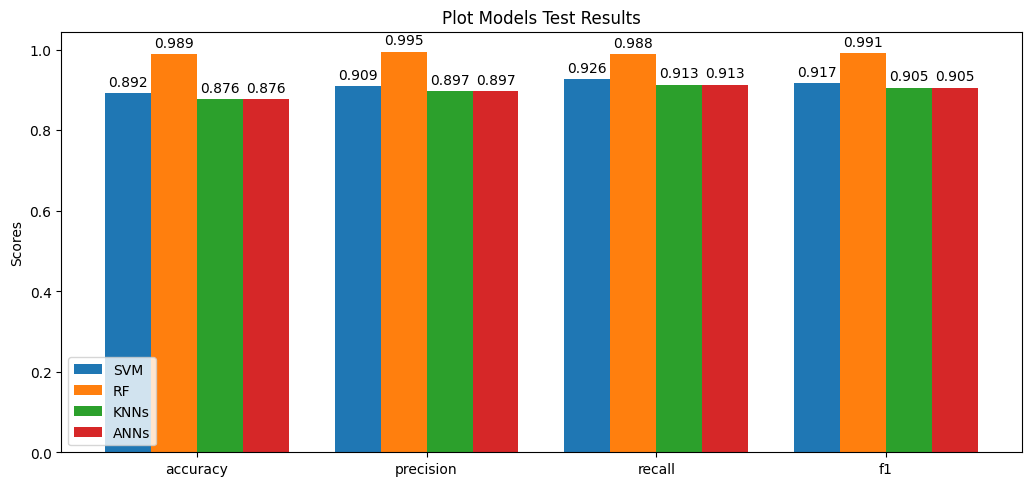

In [122]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data
labels = ['accuracy', 'precision', 'recall', 'f1']
values_a = list(map(lambda x: round(x,3), final_scores['SVM'].to_list()))
values_b = list(map(lambda x: round(x,3), final_scores['RF'].to_list()))
values_c = list(map(lambda x: round(x,3), final_scores['KNNs'].to_list()))
values_d = list(map(lambda x: round(x,3), final_scores['ANNs'].to_list()))

x = np.arange(len(labels))  # label locations
width = 0.20  # width of each bar

fig, ax = plt.subplots()

# Create grouped bars with offsets
rects1 = ax.bar(x - width*(2 - 0.5), values_a, width, label='SVM')
rects2 = ax.bar(x - width*0.5, values_b, width, label='RF')
rects3 = ax.bar(x + width*0.5, values_c, width, label='KNNs')
rects4 = ax.bar(x + width*(2 - 0.5), values_c, width, label='ANNs')

# Add labels, title, and legend
ax.set_ylabel('Scores')
ax.set_title('Plot Models Test Results')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Add value labels on bars
for i in [rects1,rects2,rects3,rects4]:
  for txt in ax.bar_label(i, padding=3):
    txt.set(rotation=0, va='bottom')

fig.tight_layout()
fig.set_figwidth(11) # change width only
fig.set_figheight(5) # change height only
plt.show()


Text(0.5, 1.0, 'Support Vector Machine')

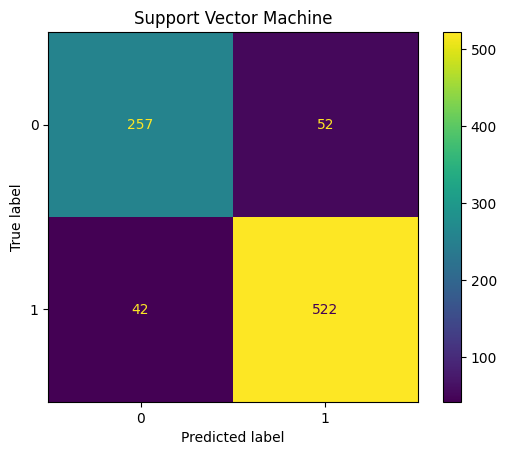

In [ ]:
ConfusionMatrixDisplay.from_estimator(final_svm_model, X_trans_test[trans_selected_feature_no_redun] , y_trans_test, display_labels=[0,1]).ax_.set_title('Support Vector Machine')

Text(0.5, 1.0, 'Random Forest')

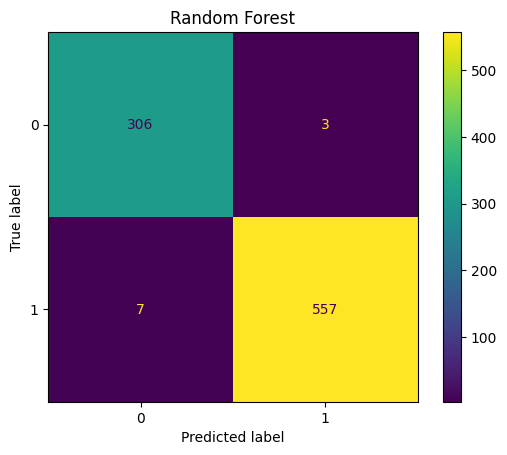

In [ ]:
ConfusionMatrixDisplay.from_estimator(final_rf_model, X_trans_test, y_trans_test, display_labels=[0,1]).ax_.set_title('Random Forest')

Text(0.5, 1.0, 'K-Nearest Neighbor')

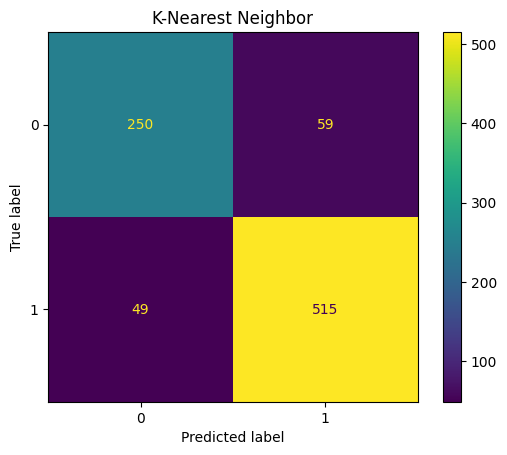

In [ ]:
ConfusionMatrixDisplay.from_estimator(final_knn_model, X_trans_test[trans_selected_feature], y_trans_test, display_labels=[0,1]).ax_.set_title('K-Nearest Neighbor')

Text(0.5, 1.0, 'Artificial Nuaral Network')

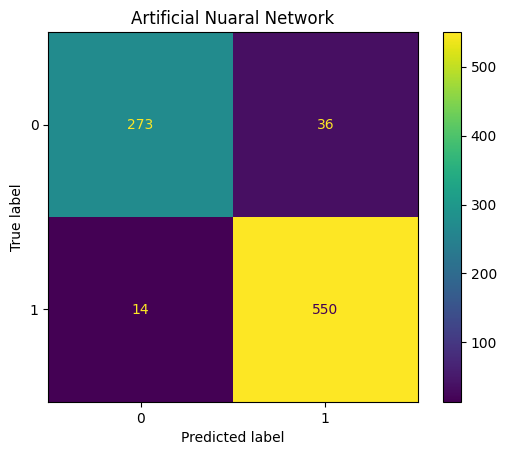

In [ ]:
ConfusionMatrixDisplay.from_estimator(final_ann_model, X_trans_test[trans_selected_feature_no_redun], y_trans_test, display_labels=[0,1]).ax_.set_title('Artificial Nuaral Network')